# Inversion on Unimak Island

This is the noteboook that solves the inversion for one InSAR geometry. VMOD works with outputs from MintPy

## Load libraries

In [1]:
%matplotlib widget
import numpy as np
import corner
import matplotlib.pyplot as plt
import matplotlib
import h5py
from vmod import util

## Plot Coherence

This cell plots the coherence so the user can choose the appropiated coherence threshold


[np.float64(-165.03240751627823), np.float64(-163.85380297107693), np.float64(54.353731366882556), np.float64(55.00885181538406)]


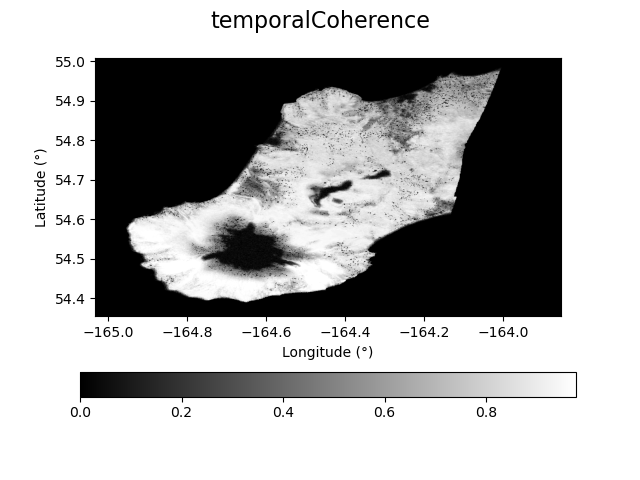

In [2]:
h5file='examples/insar/temporalCoherence_des.h5'
key='temporalCoherence'

coh=util.read_dataset_h5(h5file,key)

## Choose Area of interest

In this step the user needs to draw a box for the Area of Interest drag-clicking.

Please select the area of interest


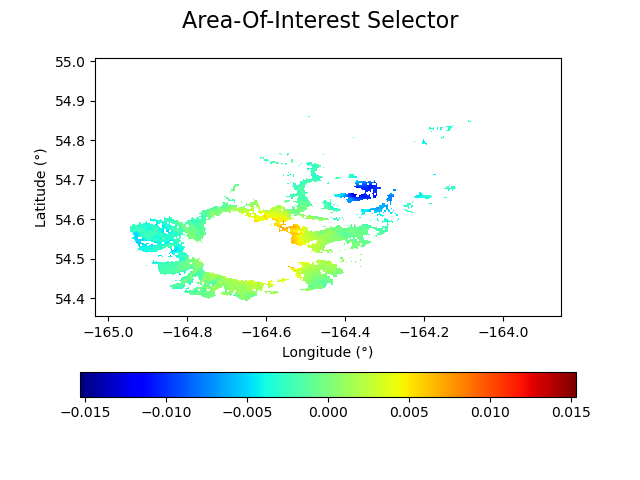

In [3]:
%matplotlib widget

h5file='examples/insar/velocity_des.h5'
key='velocity'
aoi=util.AOI_Selector(h5file,key,coh=coh,cohth=0.85)

## Choose a reference pixel

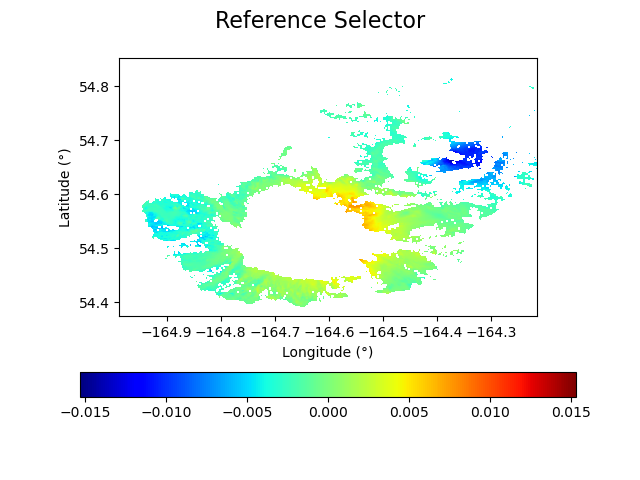

In [4]:
ref=util.Ref_Insar_Selector_Pre(aoi)

## Plot Incidence and Azimuth angles from AOI

In [5]:
mask_des=np.isnan(ref.dataset)
np.save('mask_des.npy',mask_des)

[np.float64(-164.98771747973535), np.float64(-164.21540866405445), np.float64(54.37420546349826), np.float64(54.85278371321526)]


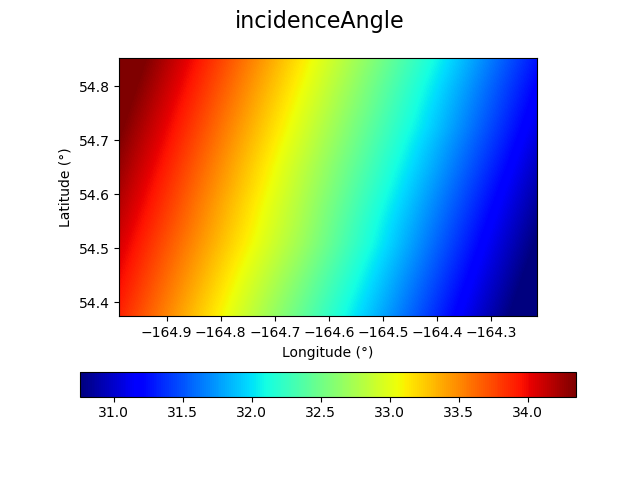

In [6]:
h5file='examples/insar/geometryGeo_des.h5'
key='incidenceAngle'
inc=util.read_dataset_h5(h5file,key,plot=True,aoi=aoi)

[np.float64(-164.98771747973535), np.float64(-164.21540866405445), np.float64(54.37420546349826), np.float64(54.85278371321526)]


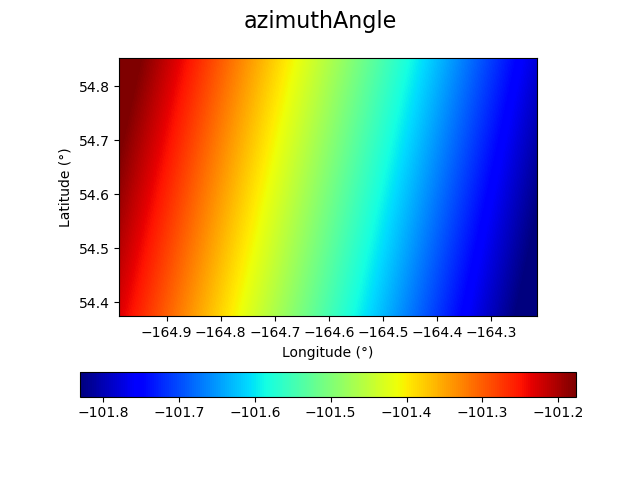

In [7]:
h5file='examples/insar/geometryGeo_des.h5'
key='azimuthAngle'
az=util.read_dataset_h5(h5file,key,plot=True,aoi=aoi)
az=-1*az+90

## Downsample the image using a Quadtree

In this cell the user can downsample the image using a quadtree that is driven by the variance. The user needs to choose a variance threshold

In [8]:
csvfile='unimak_des.csv'
util.get_quadtree(ref,az,inc,name=csvfile,th=np.nanvar(ref.dataset)/100)

/home/jovyan/notebooks/ASF/vmod_insar1/vmod/vmod/util.py:215: RuntimeWarning: Mean of empty slice
  if not np.isnan(np.nanmean(xx)):


Final samples:  1263


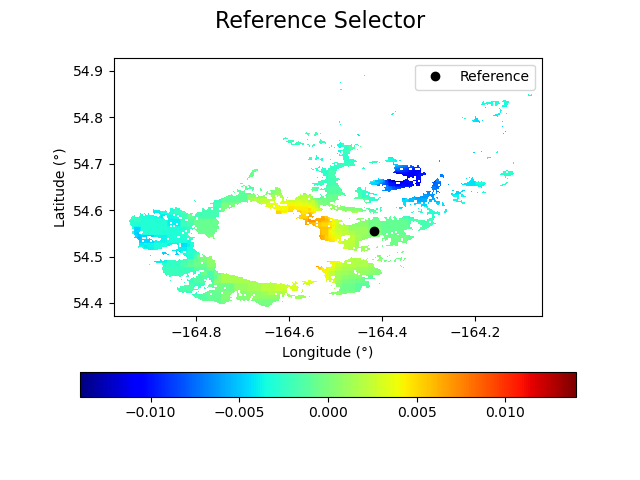

In [5]:
ref_quad=util.Ref_Insar_Selector(csvfile,mask=mask_des)

## Create the InSAR object from the downsampled image

Here the 'Insar' object is created from the csv file that has the downsampled image

In [2]:
from vmod.data import Insar
#xs,ys,azs,lks,los,elos,ref=util.read_dataset_csv('fisher.txt')
#xs,ys,azs,lks,los,elos,ref=util.read_dataset_csv('fisher_ref.txt')
#obs=Insar()
#obs.add_vecs(azs,lks)
#obs.add_xs(xs)
#obs.add_ys(ys)
#obs.add_los(los)
#obs.add_ref(ref)
#obs=util.csv2insar('fisher.txt')
csvfile_ref='unimak_des_ref.csv'
obs_des=Insar()
obs_des.importcsv(csvfile_ref,ori=[-164.5,54.7])

In [3]:
#Locations in lat/lon for the sources
#Variable for source locations
points=[(obs_des.ori[0],obs_des.ori[1])]
#Labels for the points
lpoints=['Origin(x=0, y=0)']

#Coordinates of origin in UTM
x0,y0,z1,z2=util.ll2utm([obs_des.ori[0]],[obs_des.ori[1]])

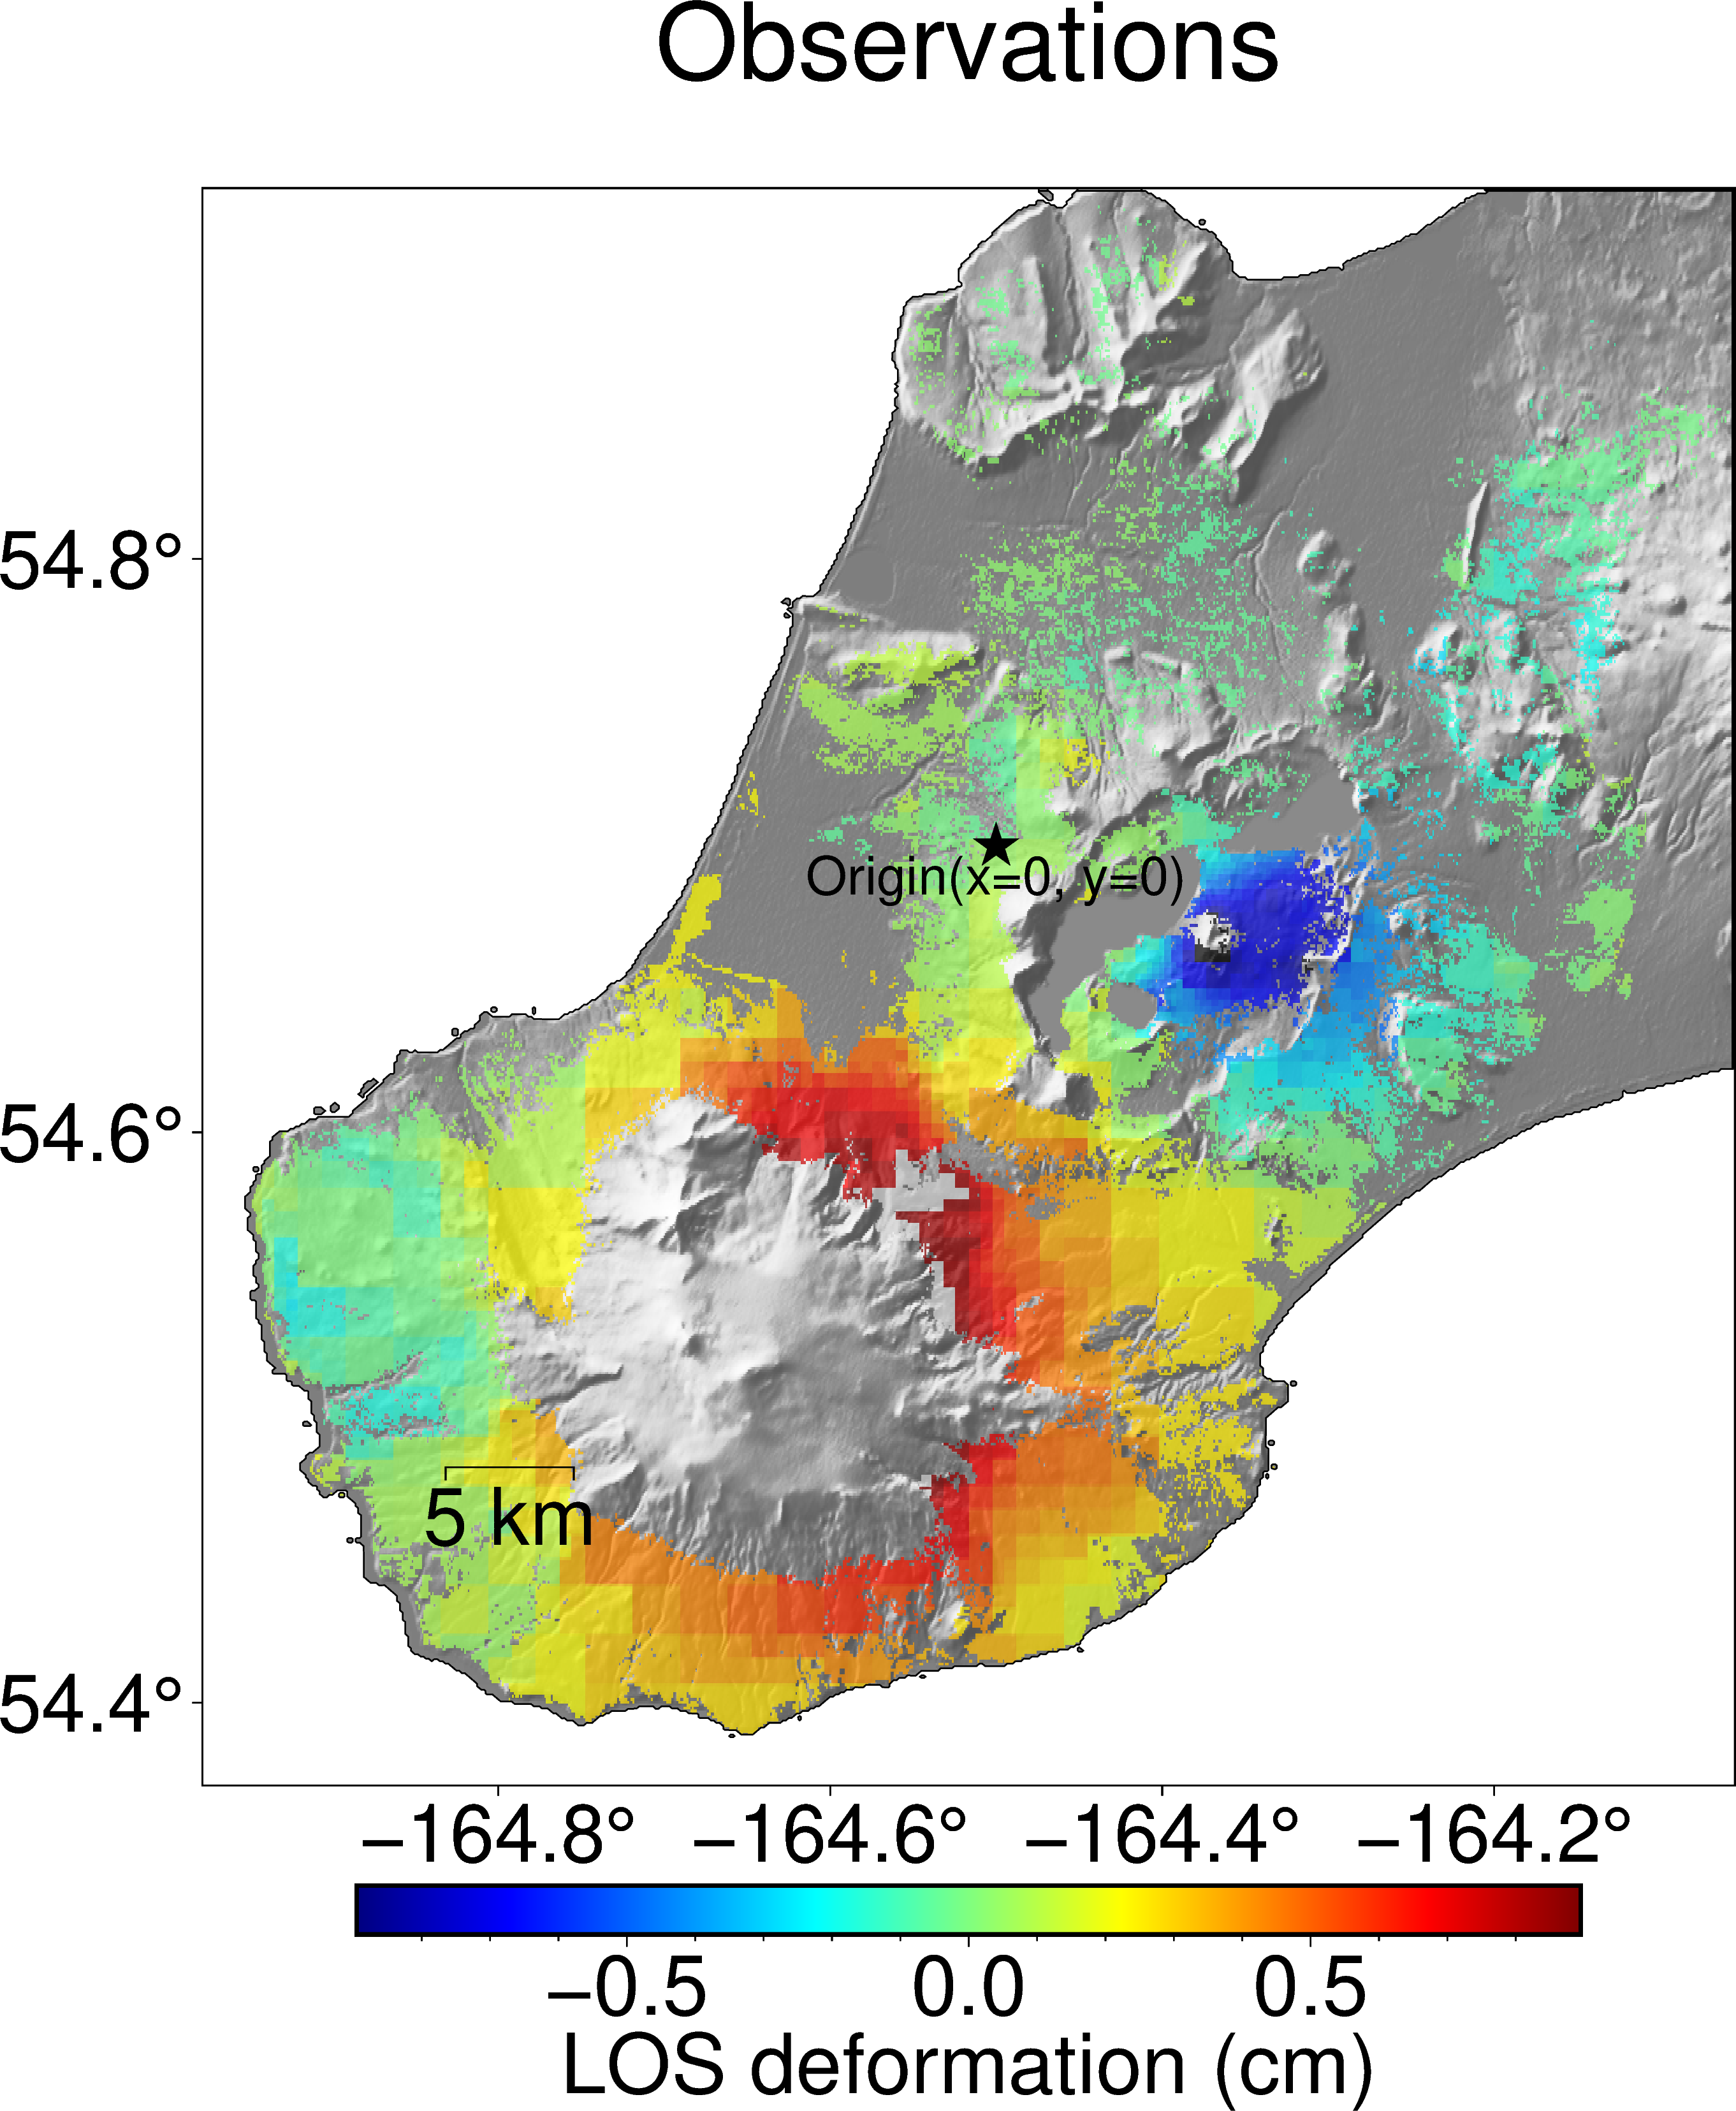

In [5]:
util.plot_insar_pygmt(obs_des.get_data(), csvfile_ref, maskfile='mask_des.npy', title='Observations', points=points, lpoints=lpoints)

## Create model objects 

Here the model objects are initialized with the bounds for the parameters. Then, the objects are added to the inversion.

In [6]:
from vmod.source import Mctigue
from vmod.source import Okada
from vmod.inverse import Inverse

okd_des = Okada(obs_des)
okd_des.set_type('open')
#Bounds for parameters
okd_des.set_bounds(low_bounds = [-20000,-20000,1e3,1e1,1e1,-100,1,1], high_bounds = [20000,20000,15e3,3e4,3e4,1,359,89])

mct_des = Mctigue(obs_des)
#Bounds for parameters
mct_des.set_bounds(low_bounds = [-30000,-30000,1e3,1e2,-0.01], high_bounds = [0,0,15e3,10e3,0.01])

inv_des=Inverse(obs_des)

inv_des.register_source(okd_des)
inv_des.register_source(mct_des)

## Run least-squares inversion

Here the non-linear least squares inversion is run

In [7]:
params=inv_des.nlsq(parallel=True, processes=16)

100%|██████████| 64/64 [00:00<00:00, 217.84it/s]


In [8]:
parnames,orders=inv_des.get_parnames_orders()
for i,parname in enumerate(parnames):
    print(parname,params[i])

xcen0 8372.26043737923
ycen0 -3425.329983112518
depth0 6406.03908544955
length0 15.367902088285327
width0 13219.33691661937
opening0 -7.5547027007923715
strike0 348.46219034742194
dip0 14.97830778778488
xcen1 -9781.52616697322
ycen1 -19357.07247460085
depth1 10227.710923418372
radius1 9999.998255397852
dP1 1.4240851707017321e-06


## Plot solution from least-squares inversion

In [9]:
#Forward model of best solution
los_des=inv_des.forward(params)

In [10]:
#Coordinates for the center of the sill
lonc1,latc1=util.utm2ll([x0+params[0]],[y0+params[1]],z1,z2)
points.append((lonc1[0][0],latc1[0][0]))
lpoints.append('Sill')

#Coordinates for the center of spherical source
lonc2,latc2=util.utm2ll([x0+params[8]],[y0+params[9]],z1,z2)
points.append((lonc2[0][0],latc2[0][0]))
lpoints.append('Sphere')

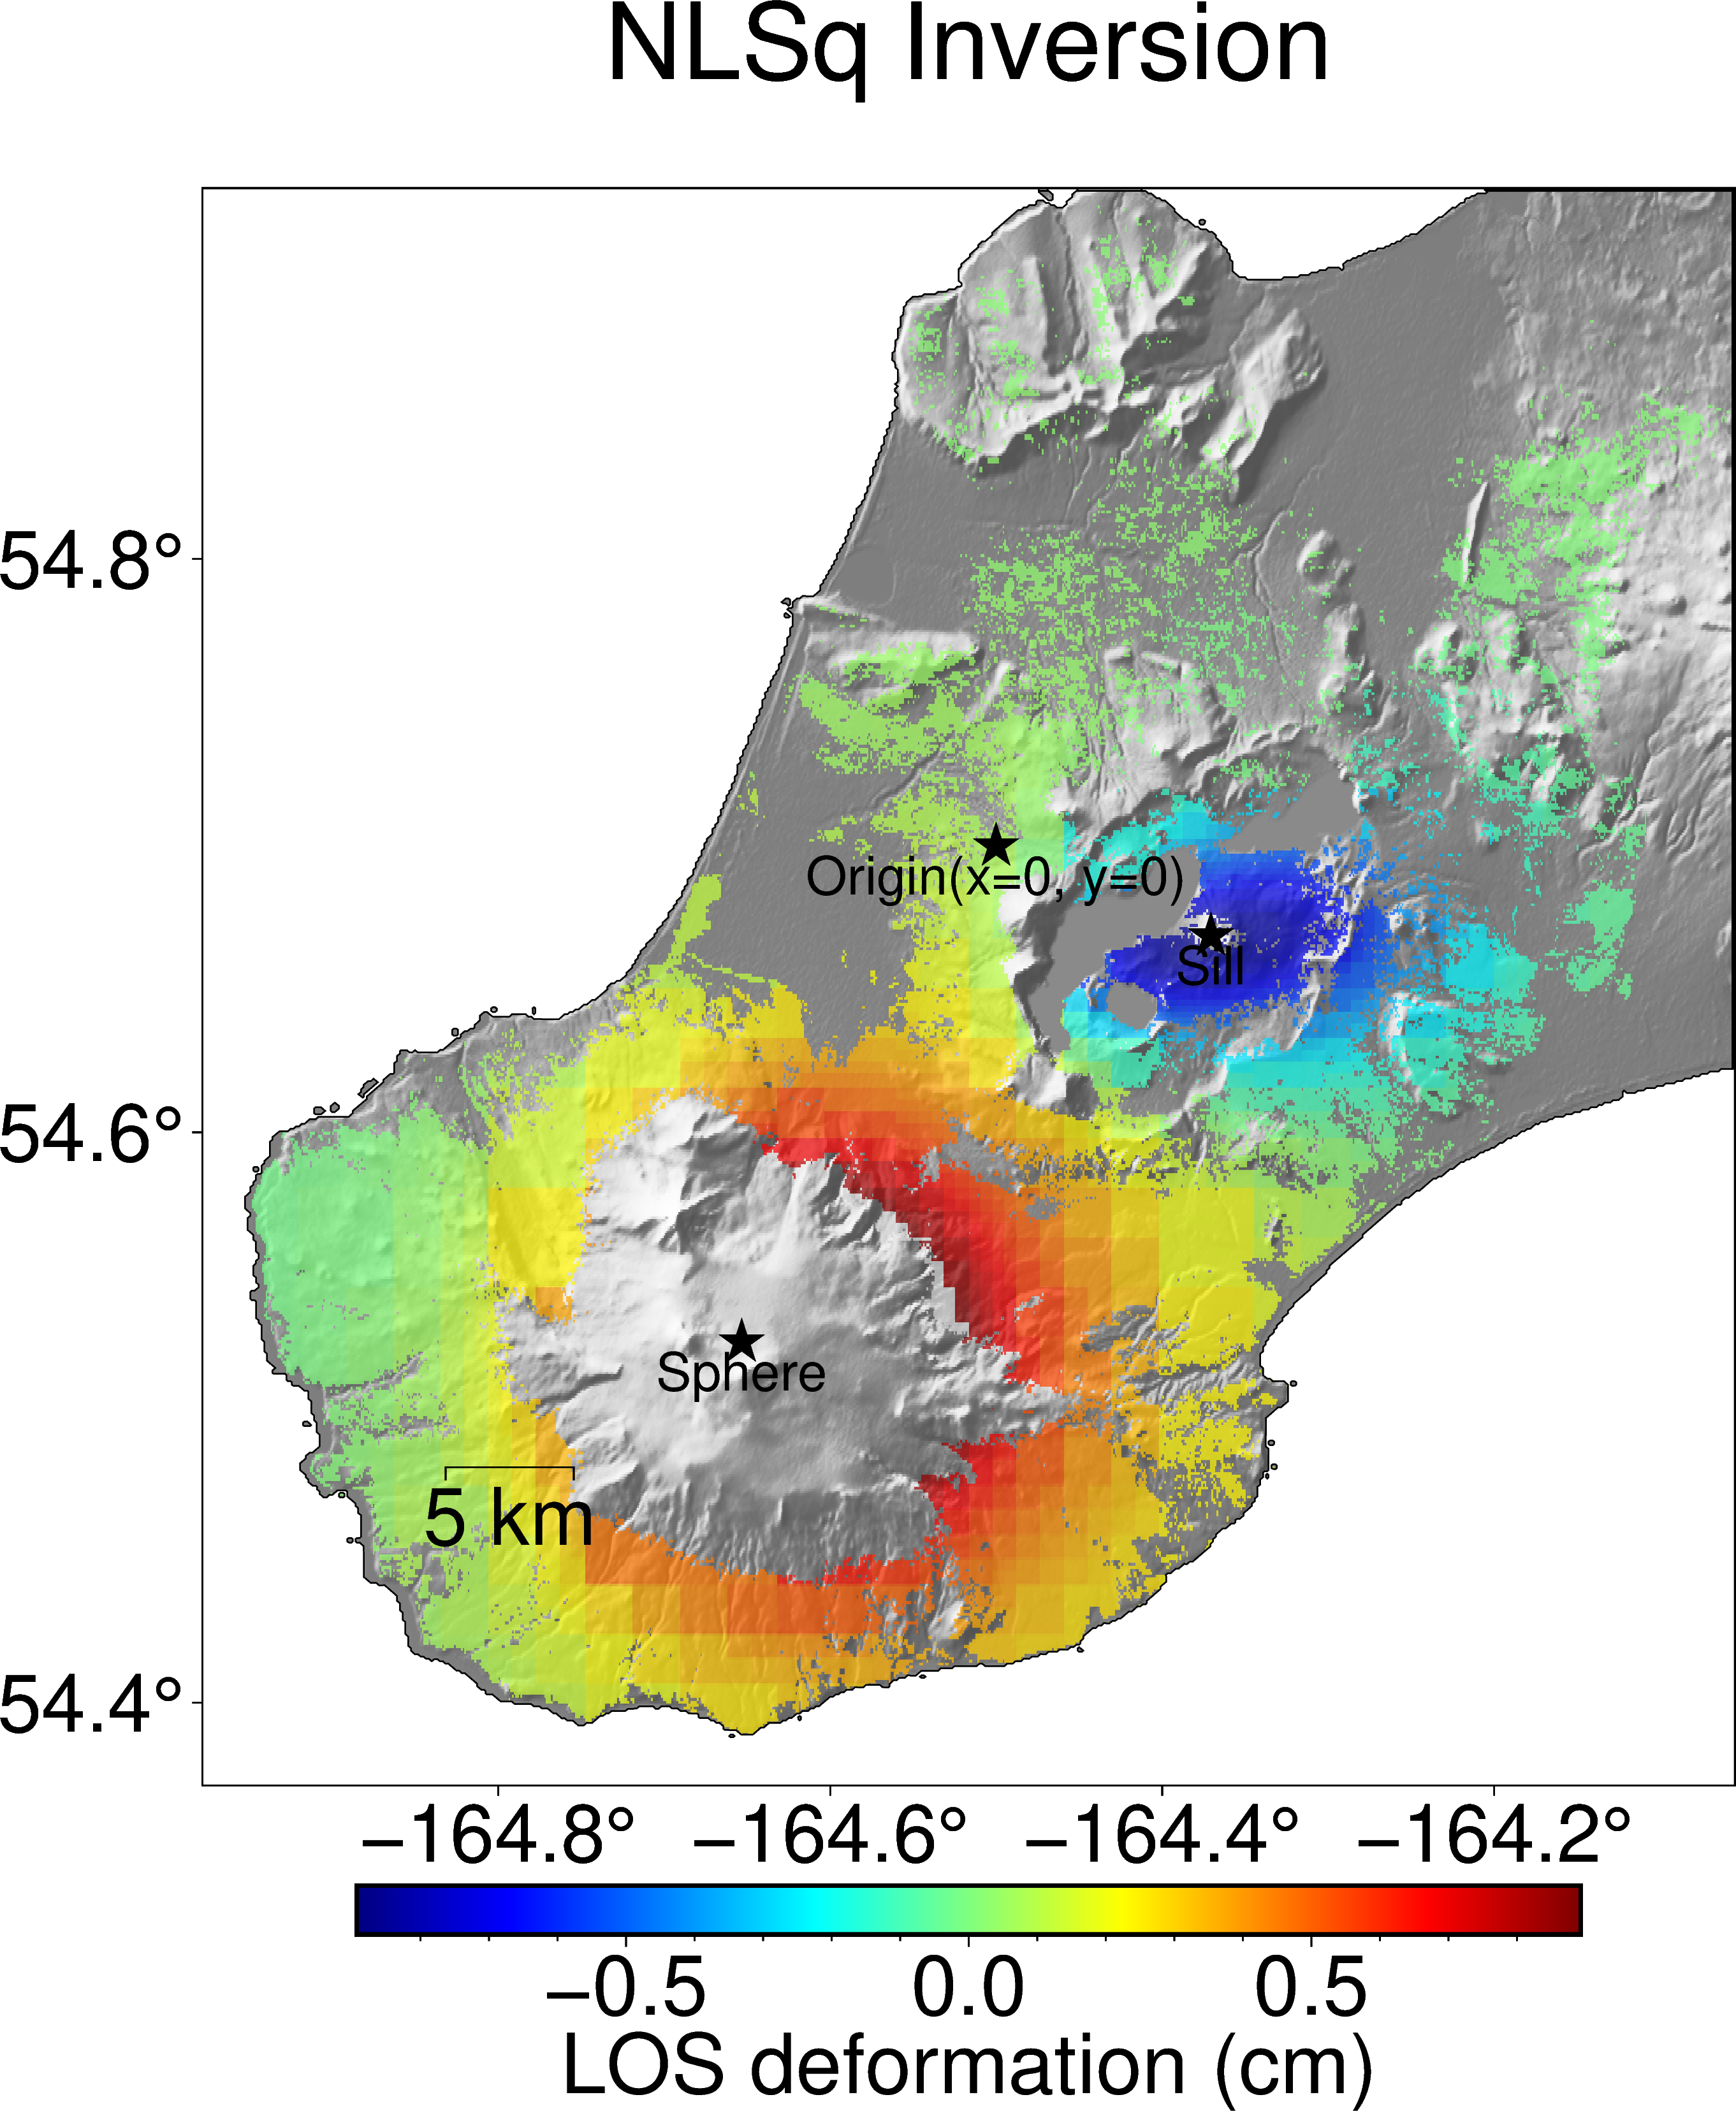

In [11]:
util.plot_insar_pygmt(los_des, csvfile_ref, maskfile='mask_des.npy', title='NLSq Inversion', points=points, lpoints=lpoints)

## Run Bayesian inversion

Here the Bayesian inversion is run. The user can interrupt the inversion at any moment and the results will be saved in a pkl file

In [18]:
trace=inv_des.mcmc_em('unimak_insar_okmc')

  0%|          | 0/235714 [00:00<?, ?it/s]/home/jovyan/.local/envs/vmod-test/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  1%|          | 1251/235714 [03:57<12:22:58,  5.26it/s]

Inversion interrupted


In [12]:
import pickle
with open('unimak_insar_okmc.pkl','rb') as handle:
    dic=pickle.load(handle)

trace=[dic[key] for key in dic.keys()]

## Plot posterior distributions for the parameters

Here we used the corner library to plot the posterior distributions for the parameters.

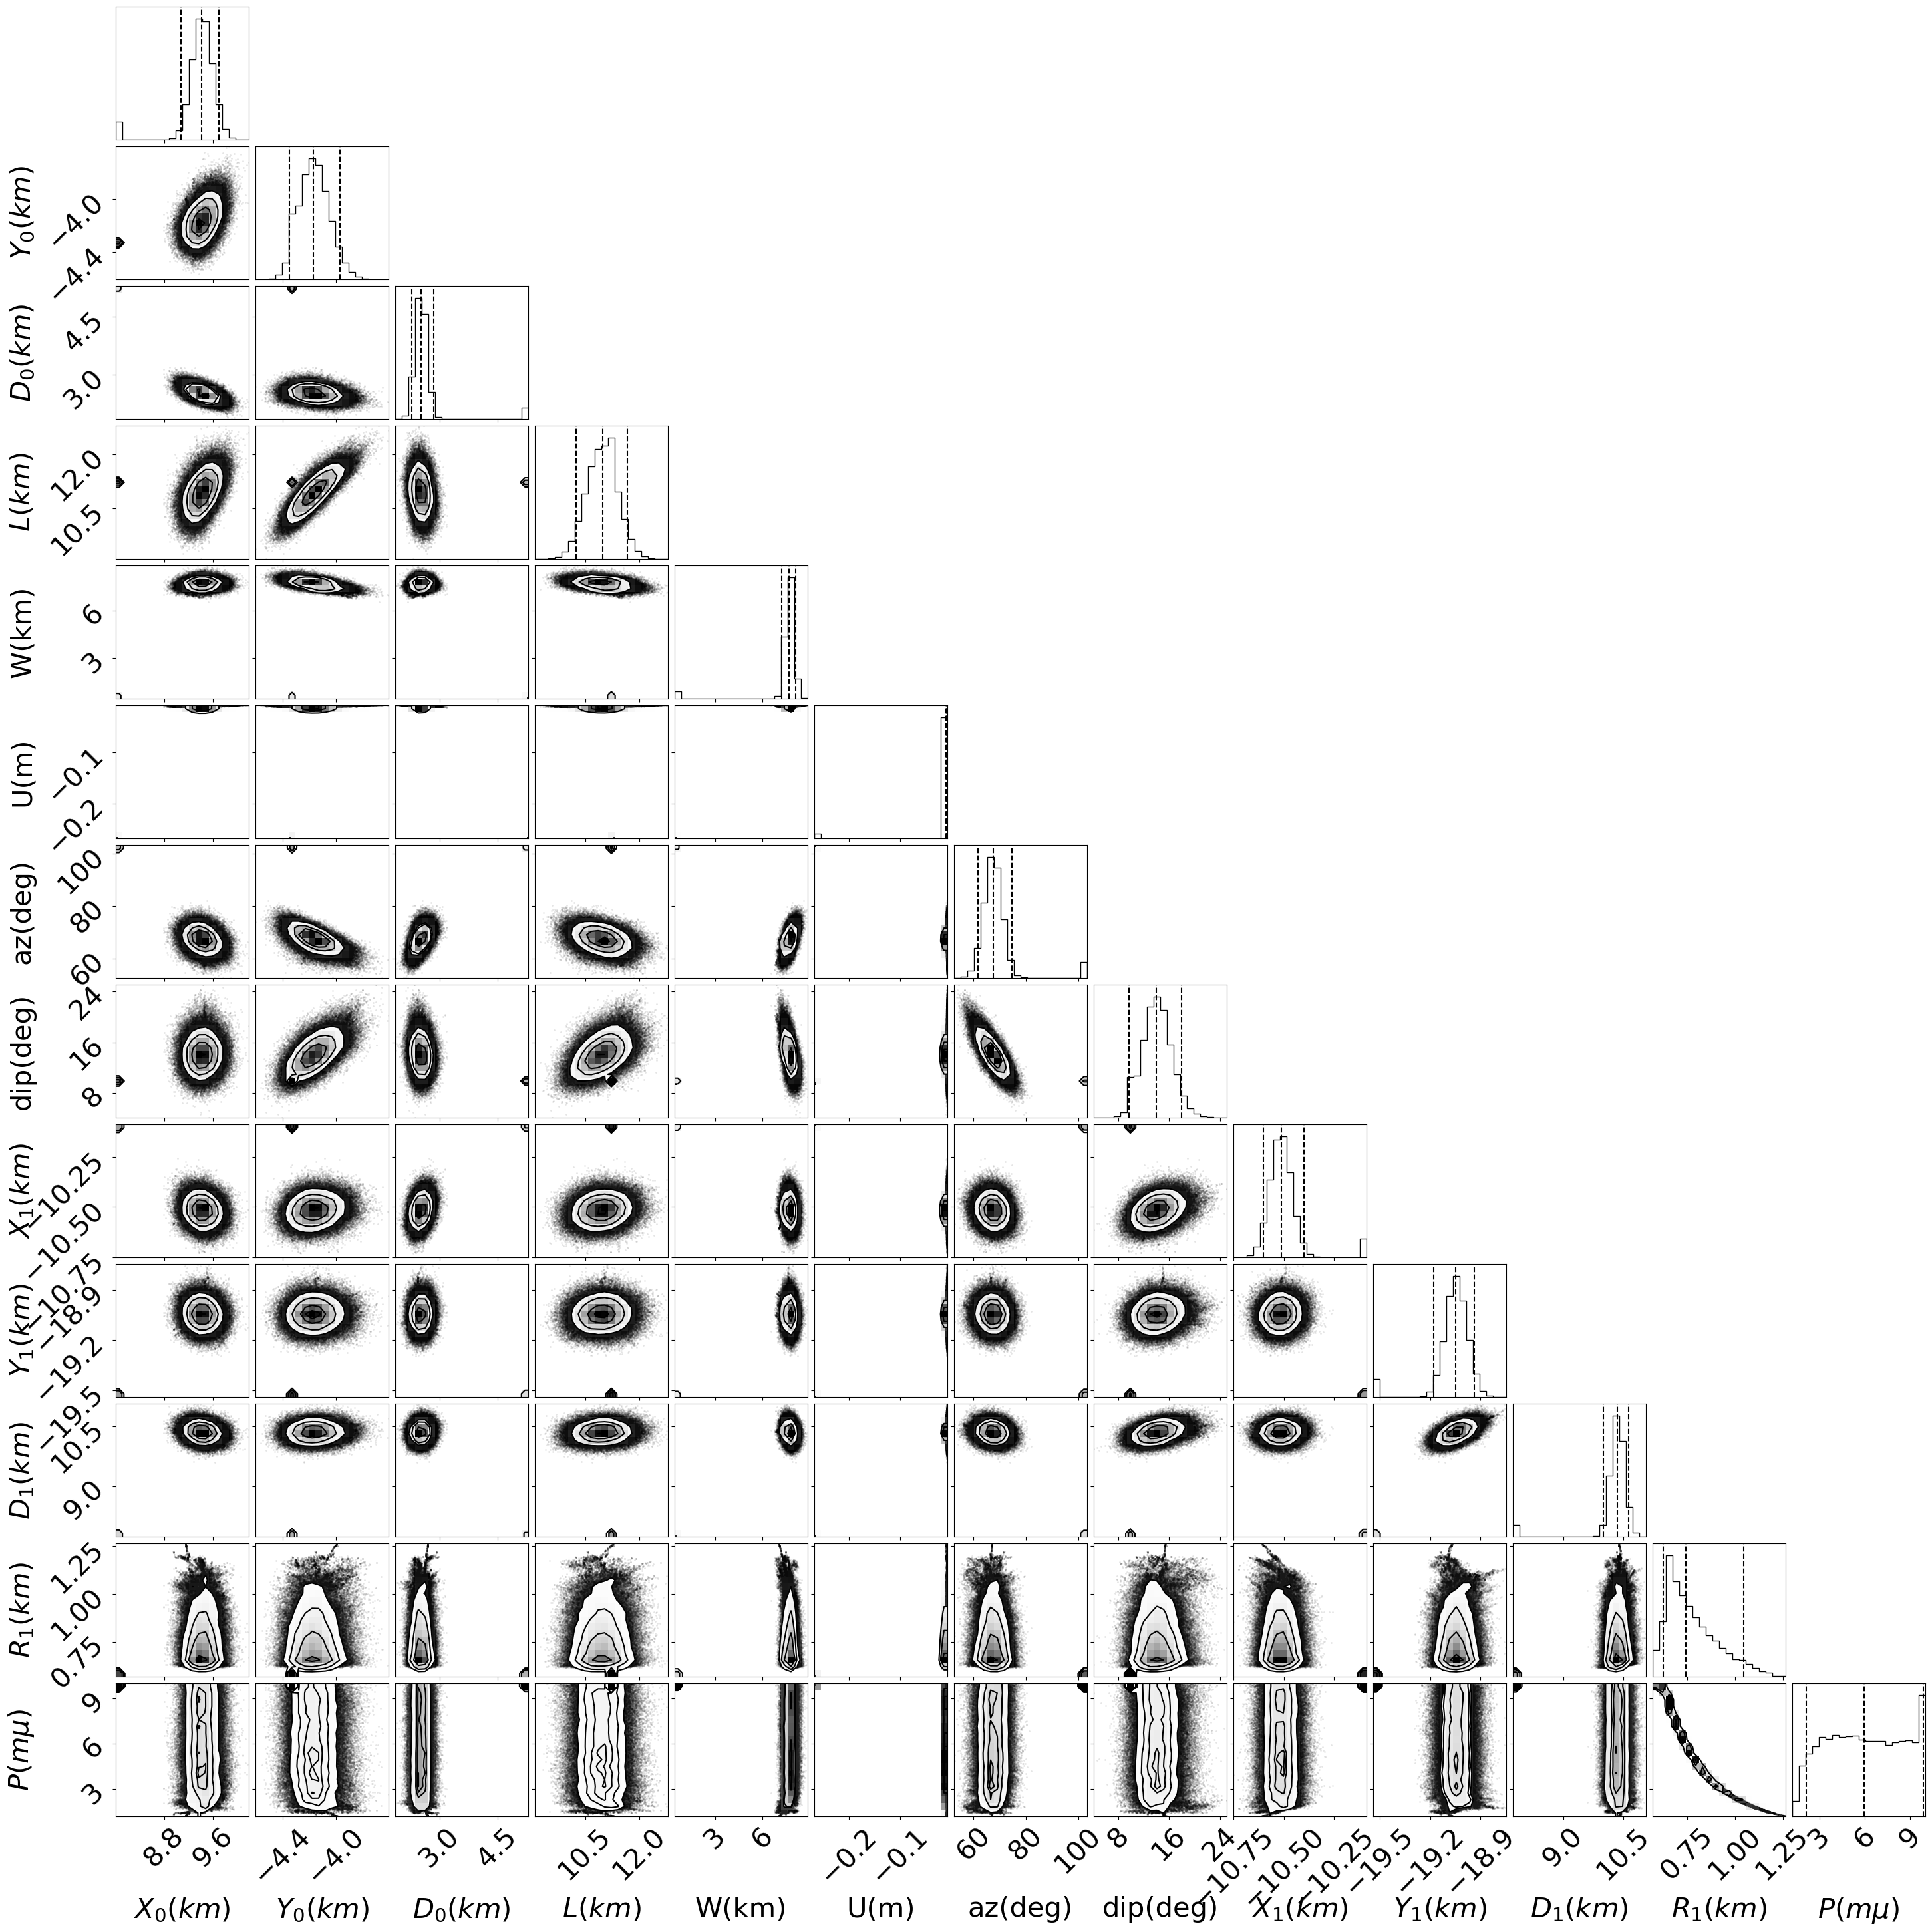

In [13]:
%matplotlib inline
data=[]
labels=[]
parnames,orders=inv_des.get_parnames_orders()
for i,tr in enumerate(trace):
    data.append(tr[:])
    labels.append(parnames[i])
data=np.vstack(data)

newdata=np.copy(data)
newdata[0:5,:]=newdata[0:5,:]/1e3
newdata[8:12,:]=newdata[8:12,:]/1e3
newdata[12,:]=newdata[12,:]*1e3

labels=[r'$X_{0} (km)$',r'$Y_{0} (km)$',r'$D_{0}(km)$','$L(km)$','W(km)','U(m)','az(deg)','dip(deg)',r'$X_{1} (km)$',r'$Y_{1} (km)$',r'$D_{1}(km)$',r'$R_{1}(km)$',r'$P(m\mu)$']

plt.rcParams.update({'font.size': 30})

figure = corner.corner(newdata.T, labels=labels,
                       quantiles=[0.05, 0.5, 0.95],max_n_ticks=3,labelpad=0.3,
                       show_titles=False, title_kwargs={"fontsize": 30})

plt.savefig('histograms')

## Find the MAP solution from the Bayesian inversion

These cells show how to find the MAP solution from the posterior distributions

In [14]:
bl=np.array([np.percentile(data[i,:],5) for i in range(data.shape[0])])
bh=np.array([np.percentile(data[i,:],95) for i in range(data.shape[0])])

import copy

obs_desn=copy.deepcopy(obs_des)
obs_desn.add_err(obs_desn.err*0+1)

okn = Okada(obs_desn)
okn.set_type('open')
#Bounds for parameters
okn.set_bounds(low_bounds = bl[0:8], high_bounds = bh[0:8])

mctn = Mctigue(obs_desn)
#Bounds for parameters
mctn.set_bounds(low_bounds = bl[8::], high_bounds = bh[8::])

invb=Inverse(obs_desn)
invb.register_source(okn)
invb.register_source(mctn)

In [15]:
paramsn=invb.nlsq()

100%|██████████| 64/64 [06:48<00:00,  6.38s/it]


In [16]:
#Variable for uncertainties in the locations
epoints=[(0,0)]

#Coordinates for the center of the sill
lonc1,latc1=util.utm2ll([x0+paramsn[0]],[y0+paramsn[1]],z1,z2)
lonmin1,latmin1=util.utm2ll([x0+np.percentile(data[0,:],5)],[y0+np.percentile(data[1,:],5)],z1,z2)
lonmax1,latmax1=util.utm2ll([x0+np.percentile(data[0,:],95)],[y0+np.percentile(data[1,:],95)],z1,z2)

points[1]=(lonc1[0][0],latc1[0][0])
epoints.append((np.mean(np.abs([lonmin1[0][0]-lonc1[0][0],lonmax1[0][0]-lonc1[0][0]])),np.mean(np.abs([latmin1[0][0]-latc1[0][0],latmax1[0][0]-latc1[0][0]]))))

#Coordinates for the center of spherical source
lonc2,latc2=util.utm2ll([x0+paramsn[8]],[y0+paramsn[9]],z1,z2)
lonmin2,latmin2=util.utm2ll([x0+np.percentile(data[8,:],5)],[y0+np.percentile(data[9,:],5)],z1,z2)
lonmax2,latmax2=util.utm2ll([x0+np.percentile(data[8,:],95)],[y0+np.percentile(data[9,:],95)],z1,z2)

points[2]=(lonc2[0][0],latc2[0][0])
epoints.append((np.mean(np.abs([lonmin2[0][0]-lonc2[0][0],lonmax2[0][0]-lonc2[0][0]])),np.mean(np.abs([latmin2[0][0]-latc2[0][0],latmax2[0][0]-latc2[0][0]]))))

## Plot MAP solution

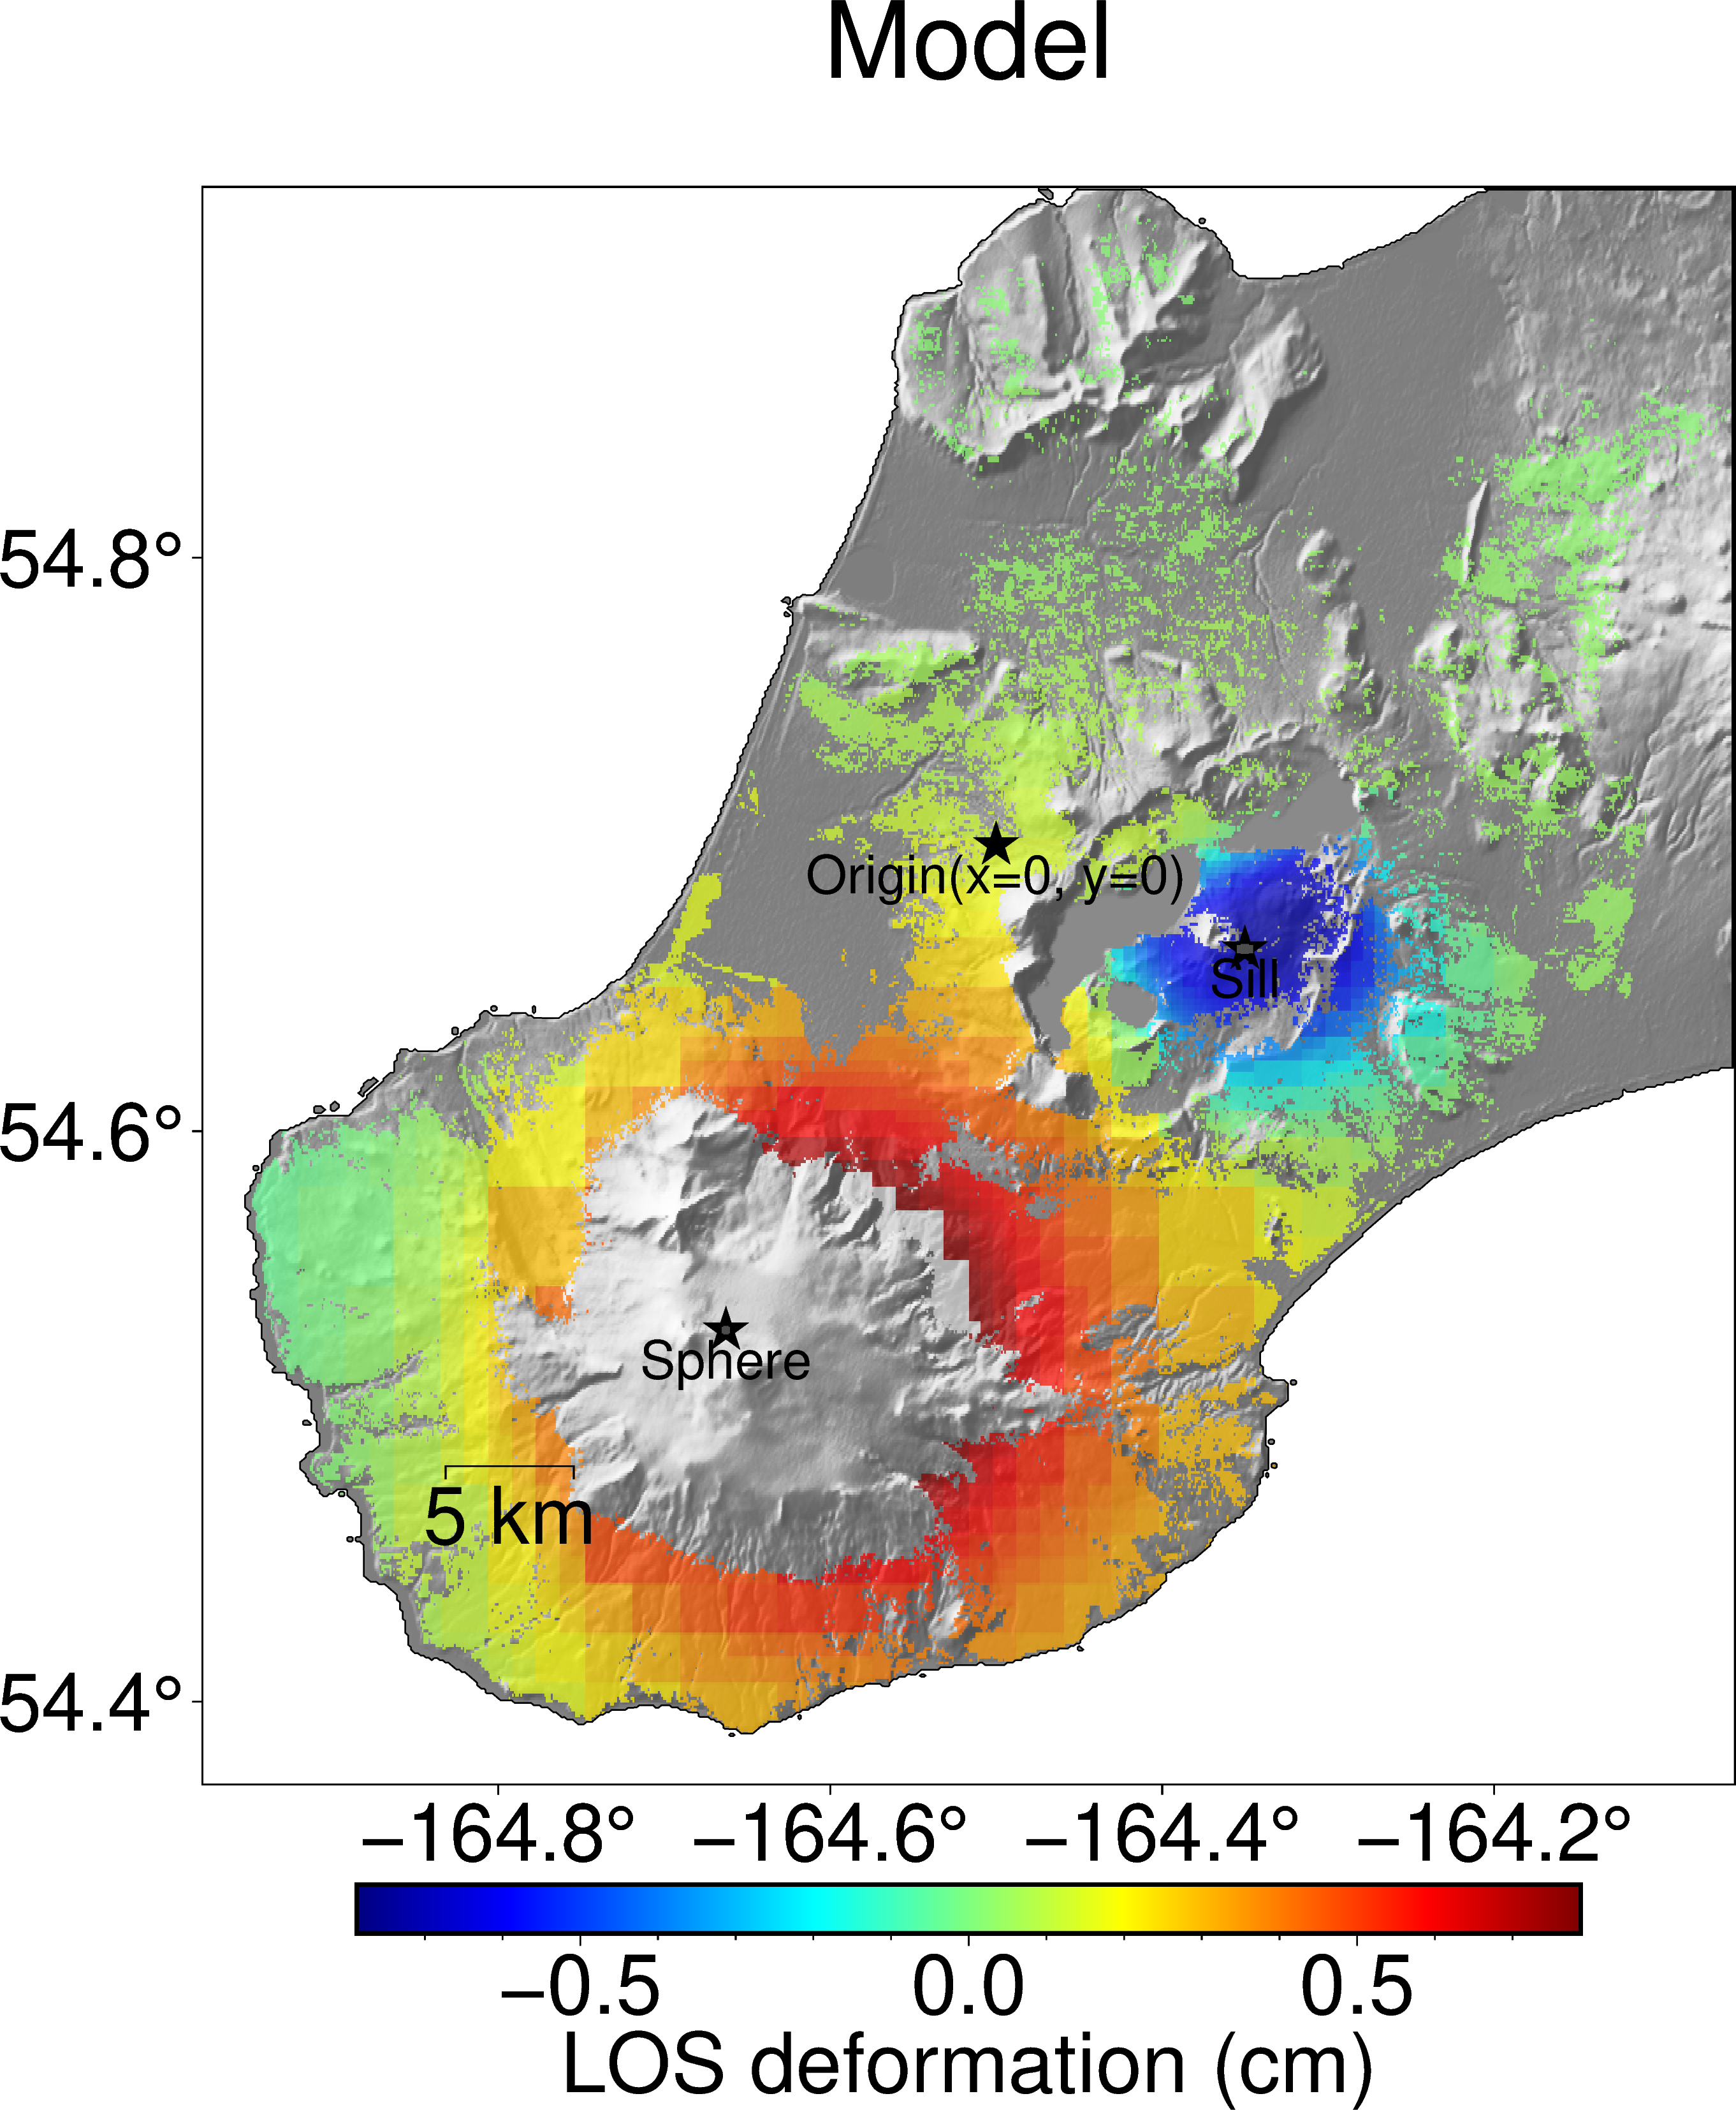

In [17]:
los_des=invb.forward(paramsn)

util.plot_insar_pygmt(los_des, csvfile_ref, maskfile='mask_des.npy', points=points, epoints=epoints, lpoints=lpoints, title='Model')

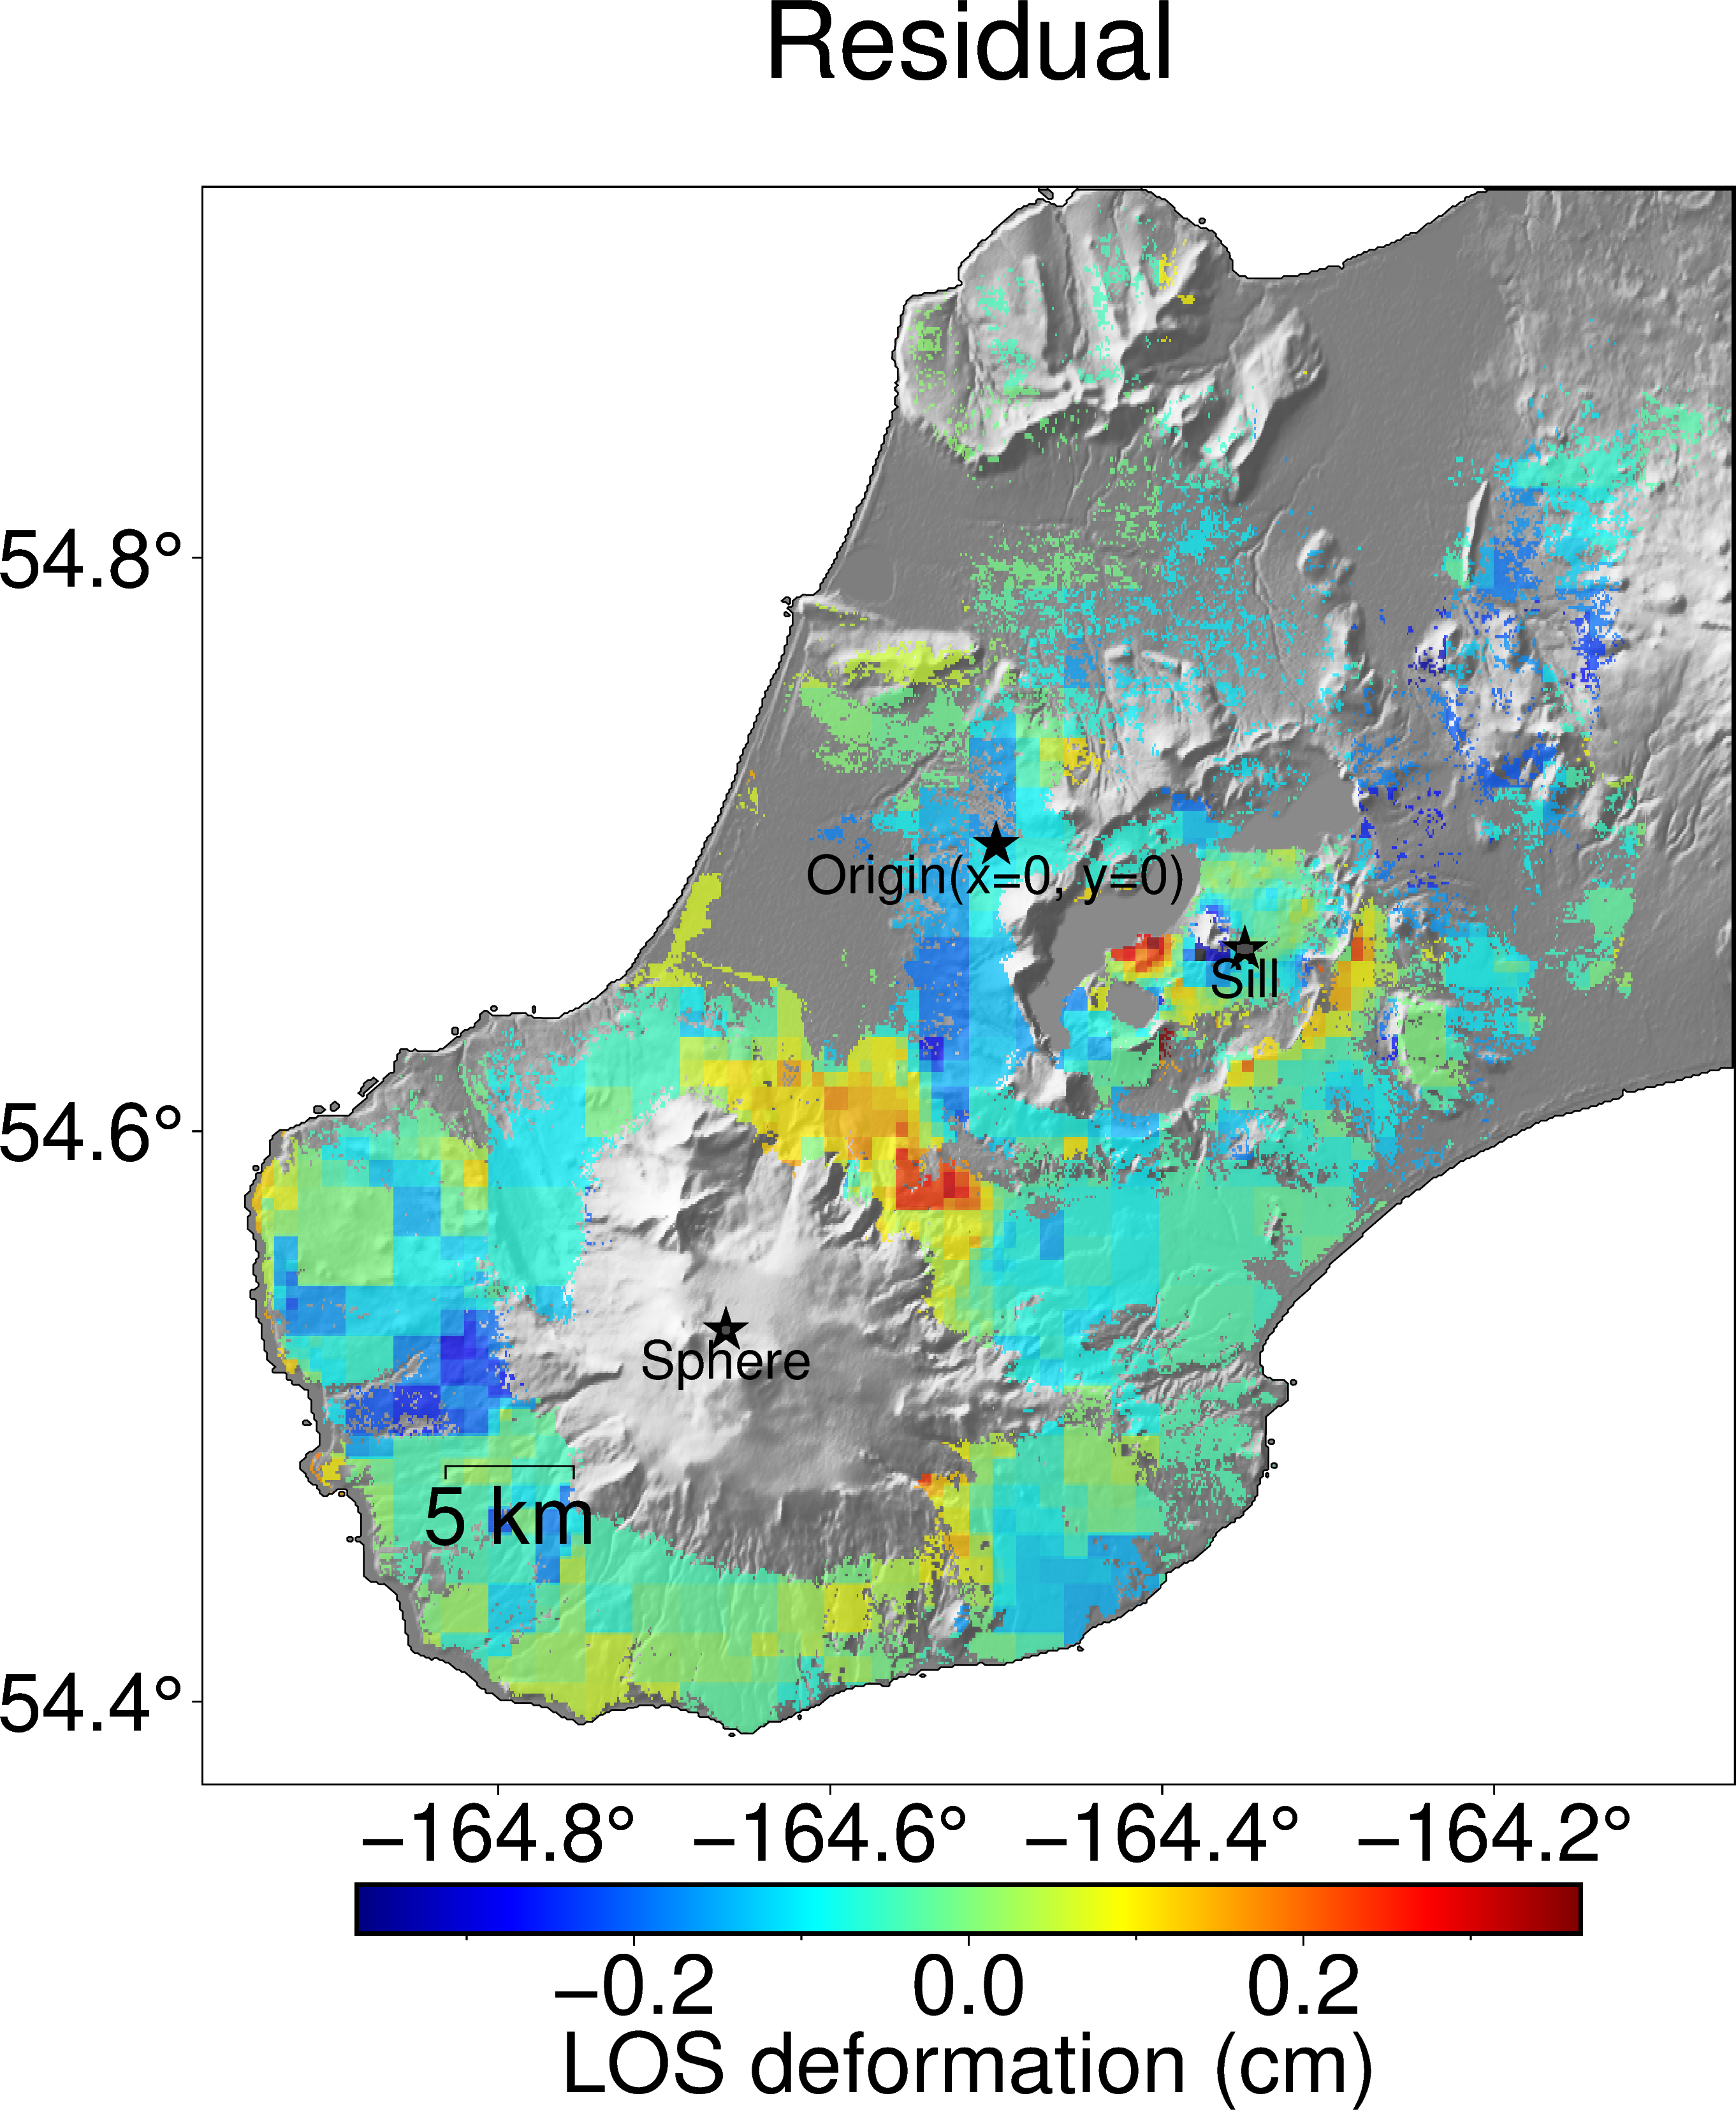

In [18]:
util.plot_insar_pygmt(obs_des.get_data()-los_des, csvfile_ref, maskfile='mask_des.npy', points=points, epoints=epoints, lpoints=lpoints, title='Residual')